# HowFar — ALS Validation (04.06.2026)

## 0. Setup
Mounts Google Drive, installs fonts, configures the plot style and colour palette, and creates output directories.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

output_dirs = ['figs/ch4', 'figs/ch5', 'figs/app']
for dir_path in output_dirs:
    os.makedirs(dir_path, exist_ok=True)
print(f"Created directories: {', '.join(output_dirs)}")

Created directories: figs/ch4, figs/ch5, figs/app


## 1. Load Data
Loads `als_validation_04.06.csv` from Google Drive and prints session statistics.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from scipy import stats

FILE_PATH = "/content/drive/MyDrive/Bachelor's Thesis/HowFar measurements/als_validation_04.06.csv"

import subprocess
subprocess.run(['apt-get', 'install', '-y', 'msttcorefonts'], capture_output=True)
import matplotlib.font_manager as fm
fm._load_fontmanager(try_read_cache=False)
plt.style.use("/content/drive/MyDrive/Bachelor's Thesis/howfar.mplstyle")

C_HF  = '#51568D'  # Dusty Grape     — HowFar ALS raw signal
C_S   = '#546FA5'  # Smart Blue      — Sonel LXP-1
C_T   = '#D2B8FF'  # Mauve           — Tenmars TM-202
C_OUT = '#FC9494'  # Grapefruit Pink — Tukey outliers

LOCATION_COLORS = [
    '#546FA5', '#FC9494', '#4B3D6F', '#51568D', '#FCBD9F', '#FCE3A9',
    '#C9FCB1', '#B8FCED', '#BDE6FC', '#D2B8FF', '#C7C7FC', '#ADC9FF',
]

df = pd.read_csv(FILE_PATH, parse_dates=['datetime'])
df = df.sort_values('timestamp').reset_index(drop=True)

t_start  = df['datetime'].iloc[0]
t_end    = df['datetime'].iloc[-1]
duration = (t_end - t_start).total_seconds()

print(f'Rows     : {len(df)}')
print(f'Start    : {t_start}')
print(f'End      : {t_end}')
print(f'Duration : {duration/60:.1f} min')
print(f'Lux range: {df["alx_lx"].min():.2f} – {df["alx_lx"].max():.2f} lux')

Rows     : 524
Start    : 2026-06-04 18:00:20
End      : 2026-06-04 18:43:55
Duration : 43.6 min
Lux range: 1.84 – 8243.20 lux


## 2. Raw ALS Signal
Plots the full HowFar ALS time series for the 04.06.2026 validation session.

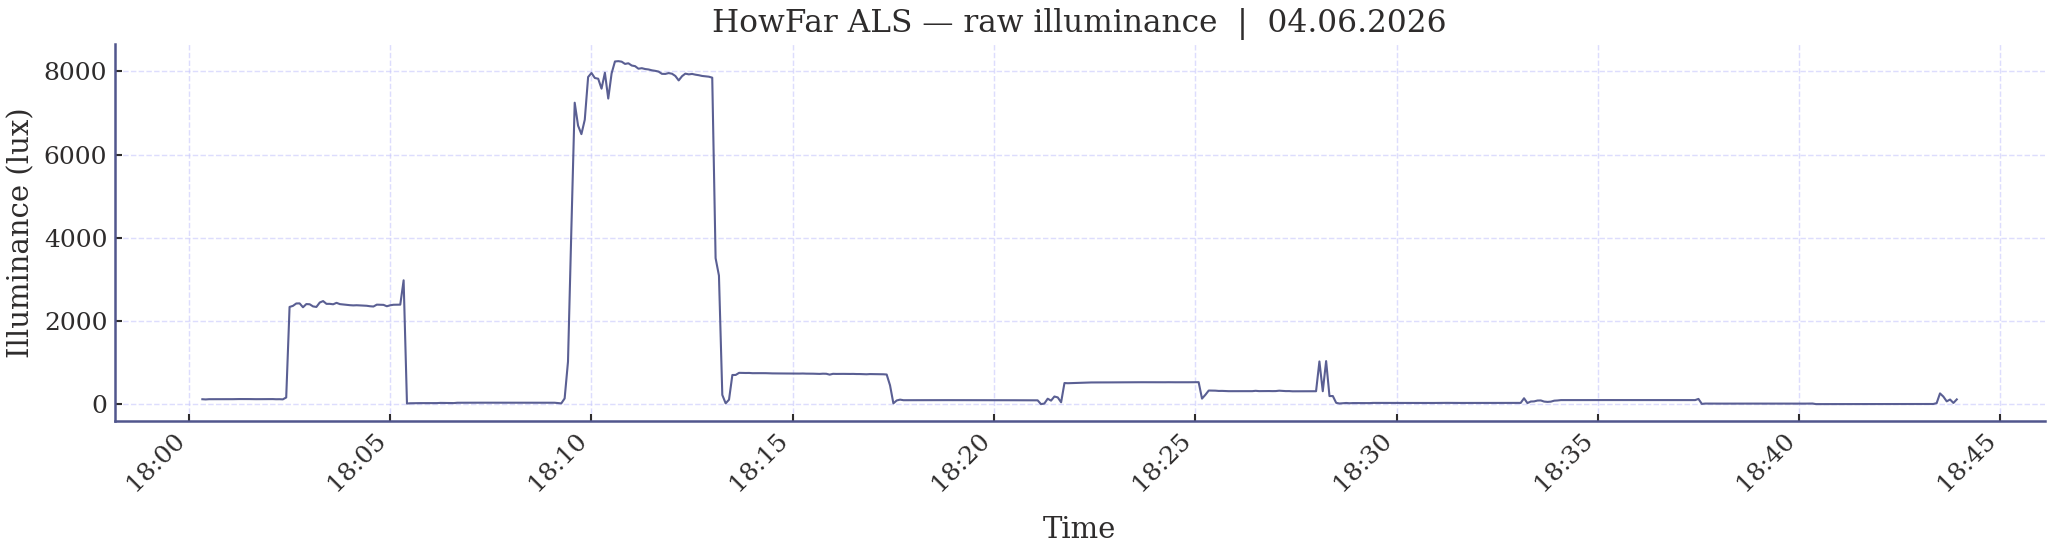

In [4]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df['datetime'], df['alx_lx'], color=C_HF, linewidth=1.0, alpha=0.95)
ax.set_xlabel('Time', labelpad=10)
ax.set_ylabel('Illuminance (lux)')
ax.set_title('HowFar ALS — raw illuminance  |  04.06.2026')
ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=5))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 3. Reference Measurements

HowFar active: **17:59 – 18:44**. Each location: 5 readings (location 11: 6 readings). Balcony values originally in kLux, converted to lux here.

In [5]:
ref_data = [
    ('Natural, shaded',          '18:00','18:02','400 lx', [200,  201,  200,  200,  200  ],'200 lx', [177,  176,  177,  176,  177  ]),
    ('Natural, near window',     '18:03','18:05','4 klx',  [2433, 2410, 2406, 2403, 2390 ],'20 klx', [2180, 2170, 2160, 2160, 2150 ]),
    ('Natural, dim',             '18:07','18:09','400 lx', [33.8, 33.8, 33.8, 33.6, 33.6],'200 lx', [37.1, 37.4, 37.3, 37.0, 37.1]),
    ('Direct sunlight',          '18:11','18:13','40 klx', [9260, 9150, 9120, 9100, 9000 ],'20 klx', [7790, 7760, 7740, 7720, 7700 ]),
    ('Mixed, bulb dominant',     '18:15','18:17','4 klx',  [738,  740,  738,  732,  733  ],'2 klx',  [777,  776,  774,  773,  771  ]),
    ('Artificial, low',          '18:19','18:21','400 lx', [87.7, 87.4, 87.2, 87.1, 86.7],'200 lx', [97.4, 97.2, 96.9, 96.7, 96.4]),
    ('Mixed, moderate',          '18:23','18:25','4 klx',  [635,  636,  635,  639,  635  ],'2 klx',  [597,  596,  596,  596,  597  ]),
    ('Natural, window-lit',      '18:26','18:28','4 klx',  [476,  473,  474,  473,  474  ],'2 klx',  [353,  352,  352,  355,  357  ]),
    ('Mixed, low',               '18:31','18:33','400 lx', [34.8, 34.7, 36.2, 35.0, 34.3],'200 lx', [35.1, 34.9, 36.3, 35.0, 34.4]),
    ('Artificial, moderate',     '18:35','18:37','400 lx', [106.6,106.2,106.6,106.4,106.5],'200 lx',[114.5,114.6,114.6,114.3,114.7]),
    ('Mixed, dim',               '18:38','18:40','400 lx', [16.2, 16.1, 16.3, 16.3, 16.2, 16.3],'20 lx',[17.1, 16.9, 16.9, 17.0, 16.9, 17.4]),
    ('Mixed, very dim',          '18:41','18:43','400 lx', [3.6,  3.6,  3.5,  3.6,  3.6  ],'20 lx',  [3.7,  3.7,  3.7,  3.8,  3.8  ]),
]

rows = []
for loc, t0, t1, s_rng, s_vals, t_rng, t_vals in ref_data:
    rows.append({
        'Location':           loc,
        'Time':               f'{t0}–{t1}',
        'Sonel range':        s_rng,
        'Sonel readings':     ', '.join(str(v) for v in s_vals),
        'Sonel mean (lux)':   round(np.mean(s_vals), 2),
        'Tenmars range':      t_rng,
        'Tenmars readings':   ', '.join(str(v) for v in t_vals),
        'Tenmars mean (lux)': round(np.mean(t_vals), 2),
    })

df_ref = pd.DataFrame(rows)
df_ref.index = range(1, len(df_ref) + 1)
df_ref.index.name = '#'
pd.set_option('display.max_colwidth', None)
pd.set_option('display.float_format', '{:.2f}'.format)
display(df_ref)

,Location,Time,Sonel range,Sonel readings,Sonel mean (lux),Tenmars range,Tenmars readings,Tenmars mean (lux)
#,,,,,,,,
1,"Natural, shaded",18:00–18:02,400 lx,"200, 201, 200, 200, 200",200.20,200 lx,"177, 176, 177, 176, 177",176.60
2,"Natural, near window",18:03–18:05,4 klx,"2433, 2410, 2406, 2403, 2390",2408.40,20 klx,"2180, 2170, 2160, 2160, 2150",2164.00
3,"Natural, dim",18:07–18:09,400 lx,"33.8, 33.8, 33.8, 33.6, 33.6",33.72,200 lx,"37.1, 37.4, 37.3, 37.0, 37.1",37.18
4,Direct sunlight,18:11–18:13,40 klx,"9260, 9150, 9120, 9100, 9000",9126.00,20 klx,"7790, 7760, 7740, 7720, 7700",7742.00
5,"Mixed, bulb dominant",18:15–18:17,4 klx,"738, 740, 738, 732, 733",736.20,2 klx,"777, 776, 774, 773, 771",774.20
6,"Artificial, low",18:19–18:21,400 lx,"87.7, 87.4, 87.2, 87.1, 86.7",87.22,200 lx,"97.4, 97.2, 96.9, 96.7, 96.4",96.92
7,"Mixed, moderate",18:23–18:25,4 klx,"635, 636, 635, 639, 635",636.00,2 klx,"597, 596, 596, 596, 597",596.40
8,"Natural, window-lit",18:26–18:28,4 klx,"476, 473, 474, 473, 474",474.00,2 klx,"353, 352, 352, 355, 357",353.80
9,"Mixed, low",18:31–18:33,400 lx,"34.8, 34.7, 36.2, 35.0, 34.3",35.00,200 lx,"35.1, 34.9, 36.3, 35.0, 34.4",35.14


## 4. ALS Signal with Reference Means
Overlays Sonel and Tenmars mean values on the full HowFar ALS time series.

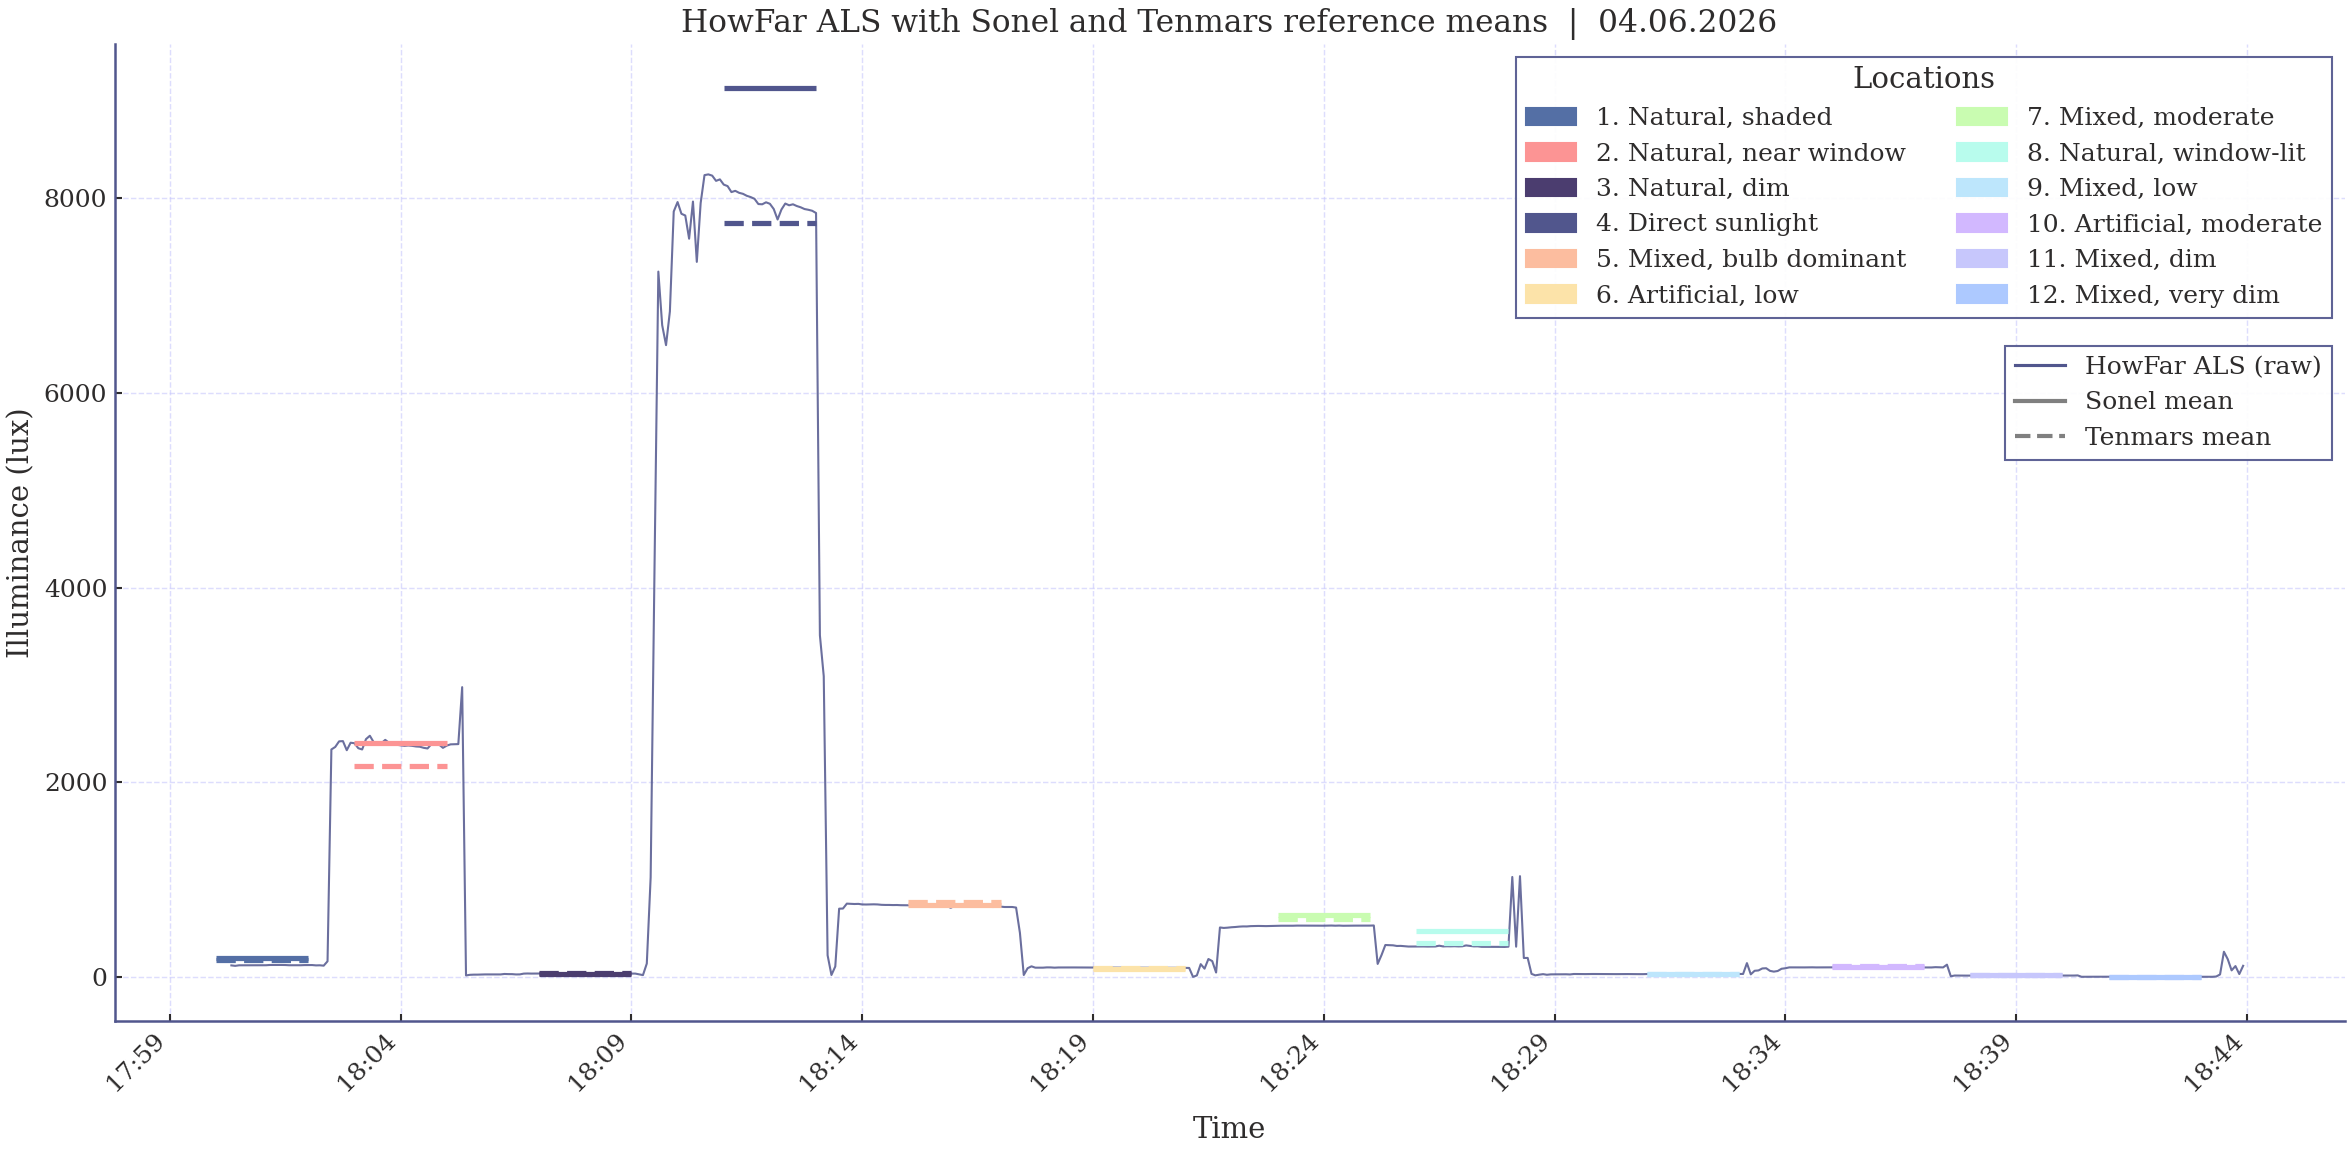

In [6]:
date_str = t_start.strftime('%Y-%m-%d')
colors = LOCATION_COLORS

fig, ax = plt.subplots(figsize=(16, 8))
ax.plot(df['datetime'], df['alx_lx'], color=C_HF, linewidth=1.0, alpha=0.85, zorder=2)
legend_patches = []
for i, (loc, t0, t1, s_rng, s_vals, t_rng, t_vals) in enumerate(ref_data):
    ts0, ts1 = pd.Timestamp(f'{date_str} {t0}:00'), pd.Timestamp(f'{date_str} {t1}:00')
    col = colors[i]
    ax.hlines(np.mean(s_vals), ts0, ts1, colors=[col], linewidths=2.5, linestyles='-',  zorder=3)
    ax.hlines(np.mean(t_vals), ts0, ts1, colors=[col], linewidths=2.5, linestyles='--', zorder=3)
    legend_patches.append(mpatches.Patch(color=col, label=f'{i+1}. {loc}'))

leg1 = ax.legend(handles=legend_patches, loc='upper right', ncol=2,
                 title='Locations', bbox_to_anchor=(1.0, 1.0))
ax.add_artist(leg1)
fig.canvas.draw()
_leg1_bot = leg1.get_window_extent(renderer=fig.canvas.get_renderer()).transformed(ax.transAxes.inverted()).y0
ax.legend(handles=[
    mlines.Line2D([], [], color=C_HF, linewidth=1.5, label='HowFar ALS (raw)'),
    mlines.Line2D([], [], color='grey', linewidth=2, linestyle='-',  label='Sonel mean'),
    mlines.Line2D([], [], color='grey', linewidth=2, linestyle='--', label='Tenmars mean'),
], loc='upper right', bbox_to_anchor=(1.0, _leg1_bot))
ax.set_xlabel('Time', labelpad=10)
ax.set_ylabel('Illuminance (lux)')
ax.set_title('HowFar ALS with Sonel and Tenmars reference means  |  04.06.2026')
ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=5))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 5. Statistical Comparison
Computes per-window mean illuminance and absolute/relative error for each of the 12 measurement locations.

In [7]:
stat_rows = []
for i, (loc, t0, t1, s_rng, s_vals, t_rng, t_vals) in enumerate(ref_data):
    ts0 = pd.Timestamp(f'{date_str} {t0}:00')
    ts1 = pd.Timestamp(f'{date_str} {t1}:00')
    hf  = df.loc[(df['datetime'] >= ts0) & (df['datetime'] <= ts1), 'alx_lx']
    sonel_mean   = np.mean(s_vals)
    tenmars_mean = np.mean(t_vals)
    hf_mean      = hf.mean()
    stat_rows.append({
        '#': i+1, 'Location': loc, 'Window': f'{t0}–{t1}',
        'HF n': len(hf), 'HF mean': round(hf_mean, 2),
        'HF median': round(hf.median(), 2), 'HF std': round(hf.std(), 2),
        'HF min': round(hf.min(), 2), 'HF max': round(hf.max(), 2),
        'Sonel mean': round(sonel_mean, 2), 'Tenmars mean': round(tenmars_mean, 2),
        'HF/Sonel ratio':   round(hf_mean / sonel_mean, 3),
        'HF/Tenmars ratio': round(hf_mean / tenmars_mean, 3),
        'HF-Sonel err %':   round((hf_mean - sonel_mean)   / sonel_mean   * 100, 1),
        'HF-Tenmars err %': round((hf_mean - tenmars_mean) / tenmars_mean * 100, 1),
    })

df_stats = pd.DataFrame(stat_rows).set_index('#')
display(df_stats)
print()
print('=== Summary ===')
print(f"Mean HF/Sonel ratio    : {df_stats['HF/Sonel ratio'].mean():.3f}")
print(f"Mean HF/Tenmars ratio  : {df_stats['HF/Tenmars ratio'].mean():.3f}")
print(f"Median HF-Sonel err %  : {df_stats['HF-Sonel err %'].median():.1f}%")
print(f"Median HF-Tenmars err %: {df_stats['HF-Tenmars err %'].median():.1f}%")

,Location,Window,HF n,HF mean,HF median,HF std,HF min,HF max,Sonel mean,Tenmars mean,HF/Sonel ratio,HF/Tenmars ratio,HF-Sonel err %,HF-Tenmars err %
#,,,,,,,,,,,,,,
1,"Natural, shaded",18:00–18:02,21,121.45,121.28,2.11,114.88,124.16,200.20,176.60,0.61,0.69,-39.30,-31.20
2,"Natural, near window",18:03–18:05,25,2387.97,2385.92,32.19,2337.28,2478.08,2408.40,2164.00,0.99,1.10,-0.80,10.30
3,"Natural, dim",18:07–18:09,25,36.34,36.48,0.16,36.16,36.48,33.72,37.18,1.08,0.98,7.80,-2.30
4,Direct sunlight,18:11–18:13,25,7958.12,7938.56,88.89,7779.84,8138.24,9126.00,7742.00,0.87,1.03,-12.80,2.80
5,"Mixed, bulb dominant",18:15–18:17,25,728.96,728.96,6.22,711.04,737.92,736.20,774.20,0.99,0.94,-1.00,-5.80
6,"Artificial, low",18:19–18:21,25,96.01,96.00,0.92,94.40,97.60,87.22,96.92,1.10,0.99,10.10,-0.90
7,"Mixed, moderate",18:23–18:25,25,527.73,527.68,0.68,526.40,528.96,636.00,596.40,0.83,0.89,-17.00,-11.50
8,"Natural, window-lit",18:26–18:28,25,314.21,313.92,3.80,309.12,324.80,474.00,353.80,0.66,0.89,-33.70,-11.20
9,"Mixed, low",18:31–18:33,25,31.00,31.04,0.44,30.40,32.32,35.00,35.14,0.89,0.88,-11.40,-11.80



=== Summary ===
Mean HF/Sonel ratio    : 0.906
Mean HF/Tenmars ratio  : 0.923
Median HF-Sonel err %  : -7.4%
Median HF-Tenmars err %: -8.5%


## 6. Windowed ALS Signal
Isolates HowFar ALS to measurement windows for direct comparison with reference means.

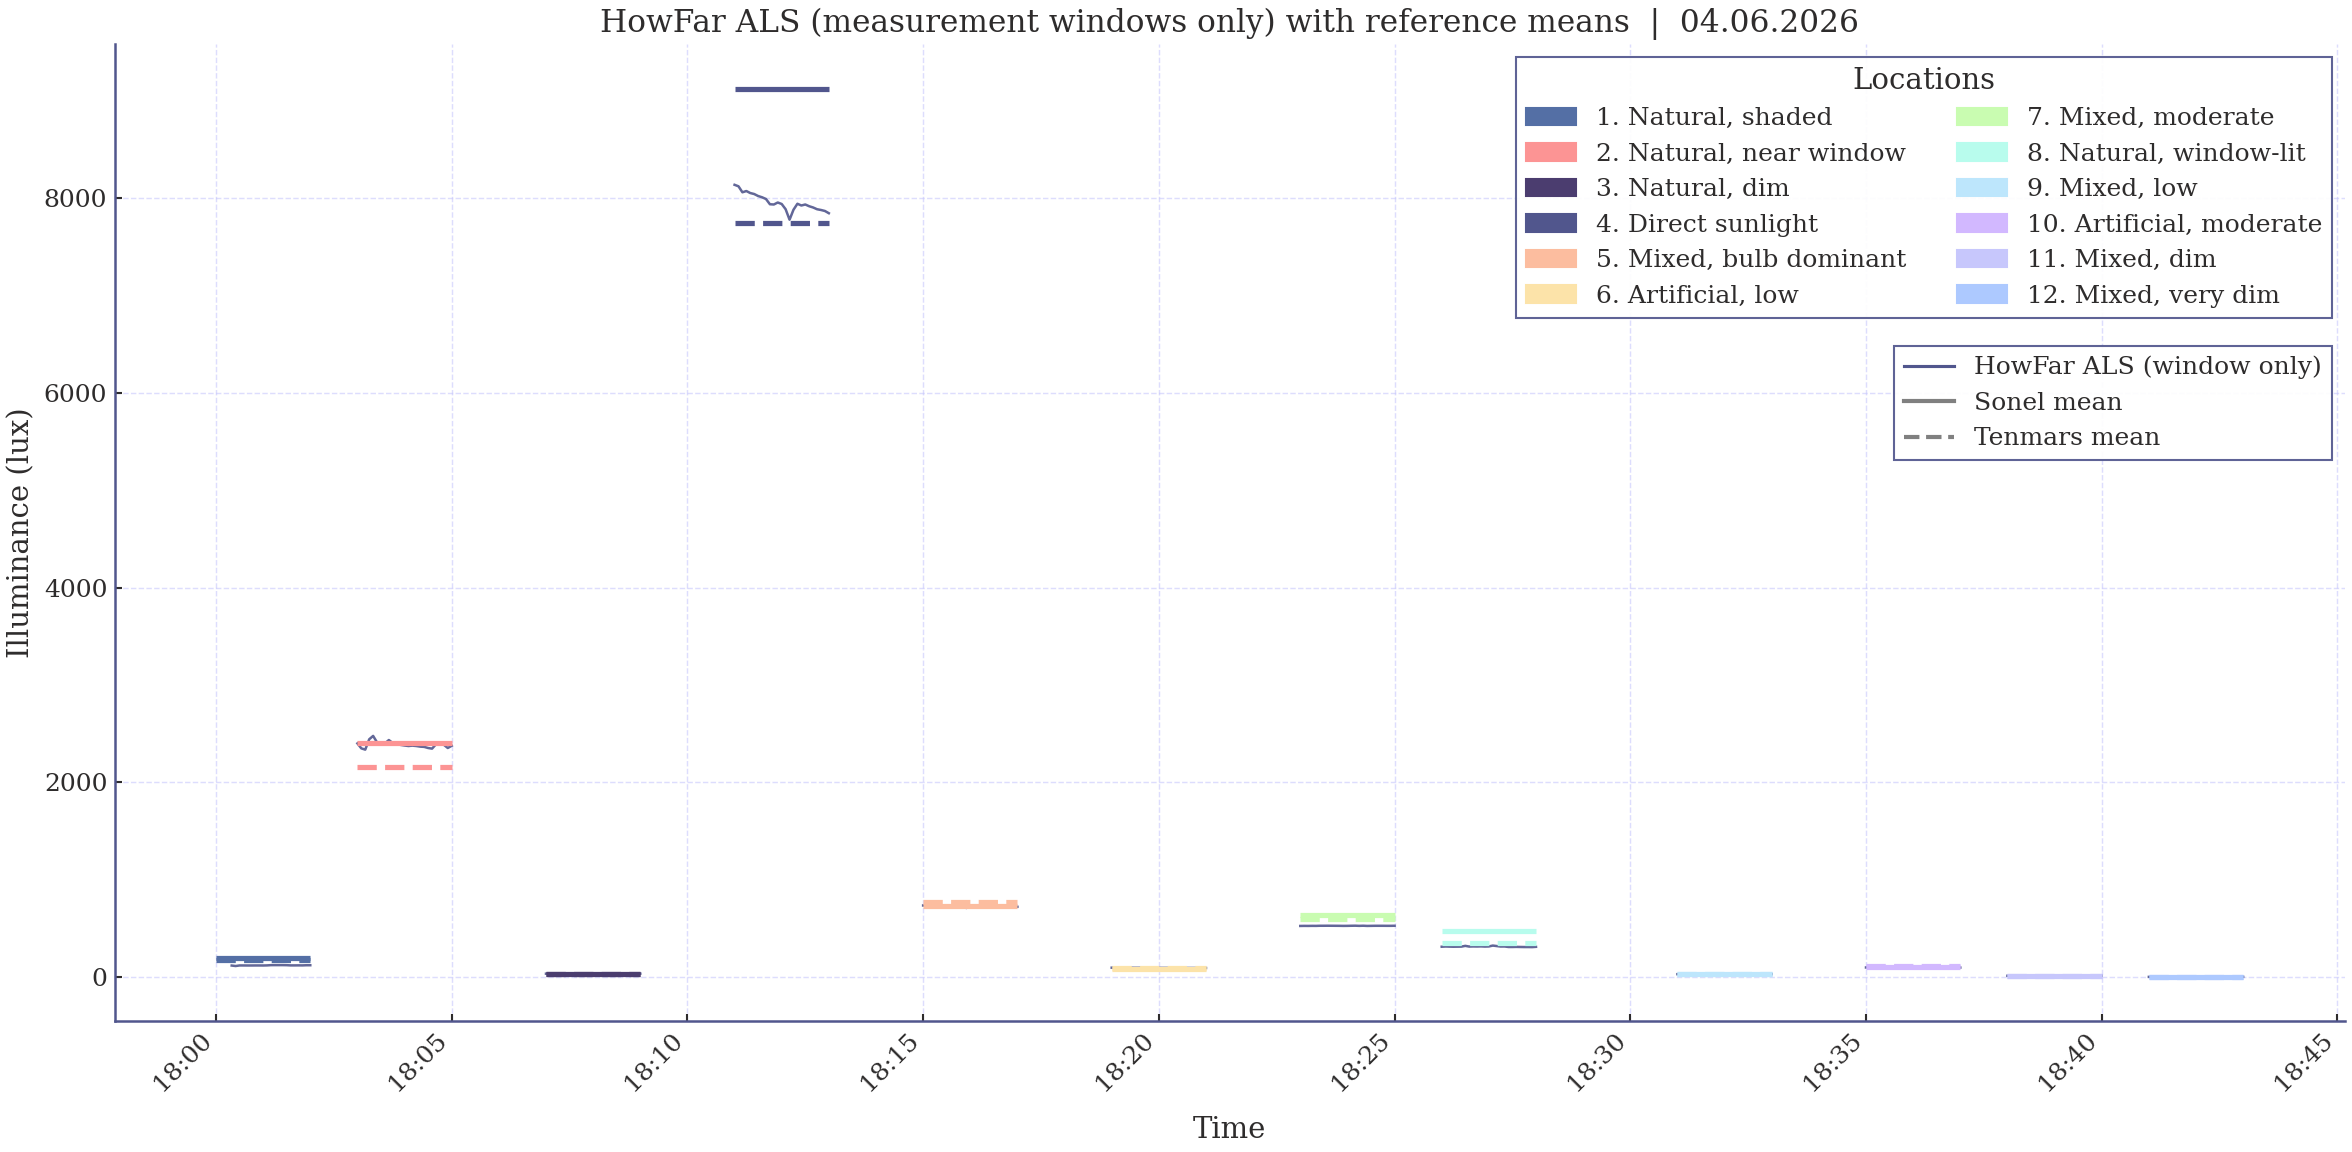

In [8]:
fig, ax = plt.subplots(figsize=(16, 8))
legend_patches = []
for i, (loc, t0, t1, s_rng, s_vals, t_rng, t_vals) in enumerate(ref_data):
    ts0, ts1 = pd.Timestamp(f'{date_str} {t0}:00'), pd.Timestamp(f'{date_str} {t1}:00')
    col = colors[i]
    seg = df.loc[(df['datetime'] >= ts0) & (df['datetime'] <= ts1)]
    ax.plot(seg['datetime'], seg['alx_lx'], color=C_HF, linewidth=1.2, alpha=0.9, zorder=2)
    ax.hlines(np.mean(s_vals), ts0, ts1, colors=[col], linewidths=2.5, linestyles='-',  zorder=3)
    ax.hlines(np.mean(t_vals), ts0, ts1, colors=[col], linewidths=2.5, linestyles='--', zorder=3)
    legend_patches.append(mpatches.Patch(color=col, label=f'{i+1}. {loc}'))

leg1 = ax.legend(handles=legend_patches, loc='upper right', ncol=2,
                 title='Locations', bbox_to_anchor=(1.0, 1.0))
ax.add_artist(leg1)
fig.canvas.draw()
_leg1_bot = leg1.get_window_extent(renderer=fig.canvas.get_renderer()).transformed(ax.transAxes.inverted()).y0
ax.legend(handles=[
    mlines.Line2D([], [], color=C_HF, linewidth=1.5, label='HowFar ALS (window only)'),
    mlines.Line2D([], [], color='grey', linewidth=2, linestyle='-',  label='Sonel mean'),
    mlines.Line2D([], [], color='grey', linewidth=2, linestyle='--', label='Tenmars mean'),
], loc='upper right', bbox_to_anchor=(1.0, _leg1_bot))
ax.set_xlabel('Time', labelpad=10)
ax.set_ylabel('Illuminance (lux)')
ax.set_title('HowFar ALS (measurement windows only) with reference means  |  04.06.2026')
ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=5))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 7. ALS Measurement Error Analysis — cf. Fig. 6, Kościółek et al. (2025)

**Tenmars TM-202** and **Sonel LXP-1** both serve as benchmarks. For each window: mean error = HowFar mean − benchmark mean; error bar = ±1 SD of HowFar samples.
Panel A: uncalibrated with linear trend lines. Panel B: after OLS calibration (separate per instrument).

Calibration vs Sonel  : HowFar = 0.8777 × Sonel   + 12.7384  R²=0.9983
Calibration vs Tenmars: HowFar = 1.0345 × Tenmars + -17.4442  R²=0.9993


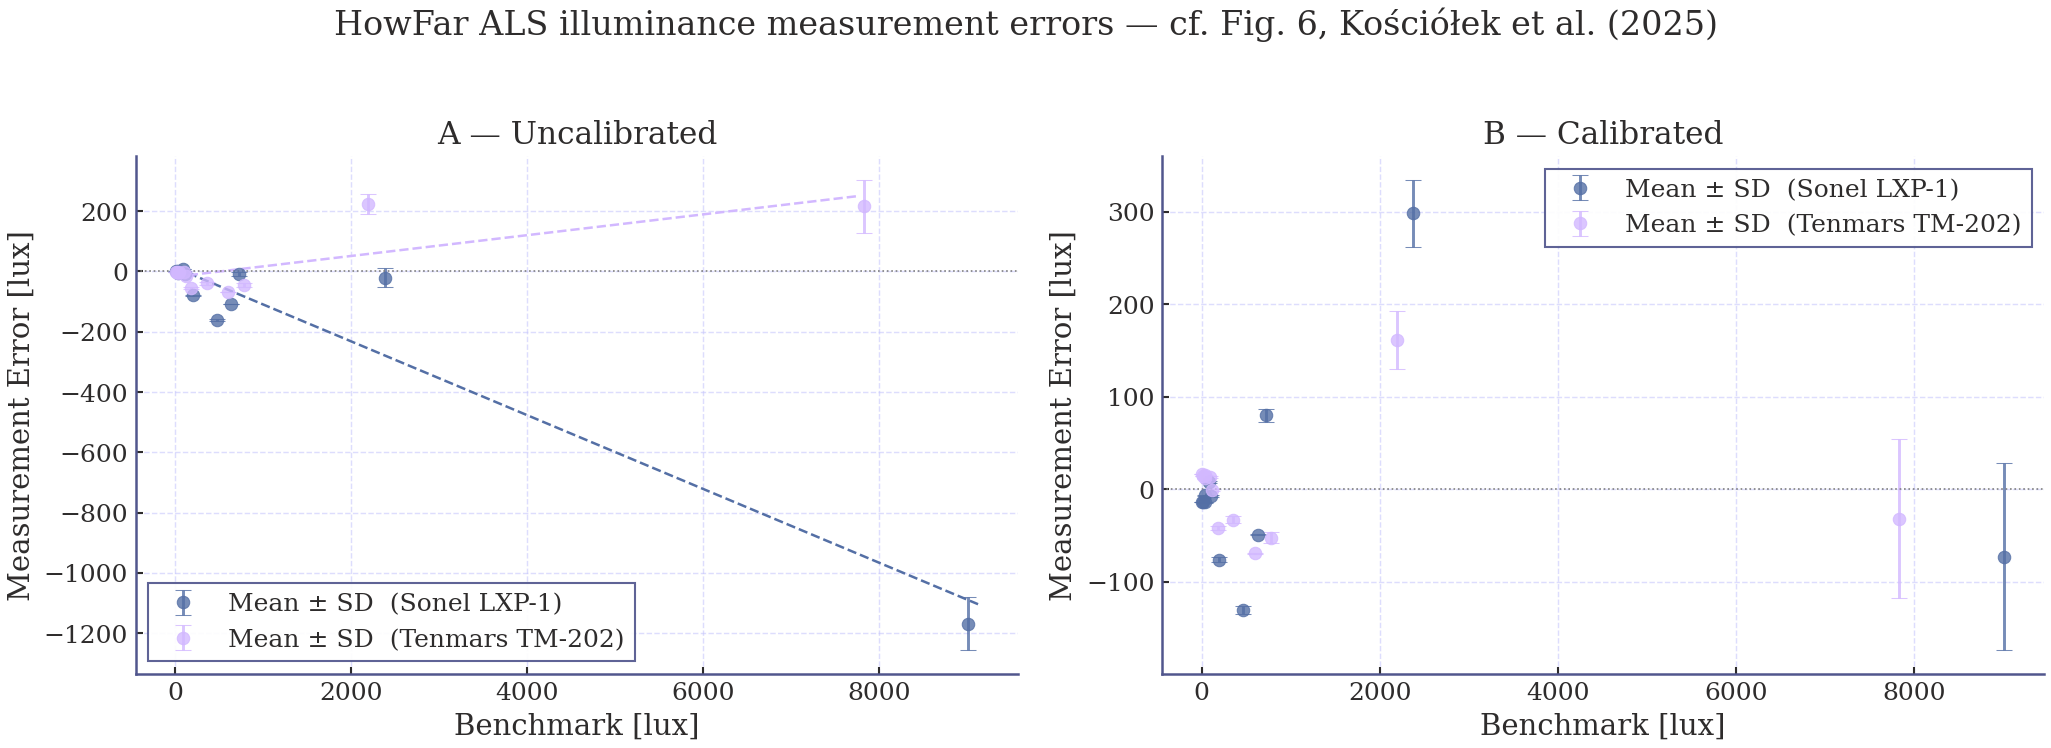


Uncalibrated vs Sonel   — mean ± SD : -128.60 ± 317.49 lux
Uncalibrated vs Tenmars — mean ± SD : 17.36 ± 93.48 lux
Calibrated   vs Sonel   — mean ± SD : -0.00 ± 102.68 lux
Calibrated   vs Tenmars — mean ± SD : -0.00 ± 56.66 lux


In [9]:
sonel_bm, tenmars_bm, hf_means, hf_stds = [], [], [], []

for loc, t0, t1, s_rng, s_vals, t_rng, t_vals in ref_data:
    ts0 = pd.Timestamp(f'{date_str} {t0}:00')
    ts1 = pd.Timestamp(f'{date_str} {t1}:00')
    hf  = df.loc[(df['datetime'] >= ts0) & (df['datetime'] <= ts1), 'alx_lx'].values
    sonel_bm.append(np.mean(s_vals))
    tenmars_bm.append(np.mean(t_vals))
    hf_means.append(np.mean(hf))
    hf_stds.append(np.std(hf, ddof=1))

sonel_bm   = np.array(sonel_bm)
tenmars_bm = np.array(tenmars_bm)
hf_means   = np.array(hf_means)
hf_stds    = np.array(hf_stds)

err_sonel   = hf_means - sonel_bm
err_tenmars = hf_means - tenmars_bm

def calibrate(bm, hfm, hfs):
    sl, ic, r, p, _ = stats.linregress(bm, hfm)
    hf_cal  = (hfm - ic) / sl
    err_cal = hf_cal - bm
    std_cal = hfs / abs(sl)
    return sl, ic, r**2, err_cal, std_cal

sl_s, ic_s, r2_s, errcal_s, stdcal_s = calibrate(sonel_bm,   hf_means, hf_stds)
sl_t, ic_t, r2_t, errcal_t, stdcal_t = calibrate(tenmars_bm, hf_means, hf_stds)

print('Calibration vs Sonel  : HowFar = {:.4f} × Sonel   + {:.4f}  R²={:.4f}'.format(sl_s, ic_s, r2_s))
print('Calibration vs Tenmars: HowFar = {:.4f} × Tenmars + {:.4f}  R²={:.4f}'.format(sl_t, ic_t, r2_t))

OFF = 0.012

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for bm, err, std, col, lbl in [
    (sonel_bm,   err_sonel,   hf_stds, C_S, 'Sonel LXP-1'),
    (tenmars_bm, err_tenmars, hf_stds, C_T, 'Tenmars TM-202'),
]:
    xoff = bm * (1 - OFF) if col == C_S else bm * (1 + OFF)
    ax.errorbar(xoff, err, yerr=std, fmt='o', color=col, ecolor=col, alpha=0.8,
                capsize=4, linewidth=1.4, markersize=6, label=f'Mean ± SD  ({lbl})')
    sl_e, ic_e, *_ = stats.linregress(bm, err)
    x_tr = np.linspace(bm.min(), bm.max(), 300)
    ax.plot(x_tr, sl_e * x_tr + ic_e, color=col, linestyle='--', linewidth=1.2)
ax.axhline(0, color='grey', linewidth=0.8, linestyle=':')
ax.set_xlabel('Benchmark [lux]')
ax.set_ylabel('Measurement Error [lux]')
ax.set_title('A — Uncalibrated')
ax.legend()

ax = axes[1]
for bm, err_cal, std_cal, col, lbl in [
    (sonel_bm,   errcal_s, stdcal_s, C_S, 'Sonel LXP-1'),
    (tenmars_bm, errcal_t, stdcal_t, C_T, 'Tenmars TM-202'),
]:
    xoff = bm * (1 - OFF) if col == C_S else bm * (1 + OFF)
    ax.errorbar(xoff, err_cal, yerr=std_cal, fmt='o', color=col, ecolor=col, alpha=0.8,
                capsize=4, linewidth=1.4, markersize=6, label=f'Mean ± SD  ({lbl})')
ax.axhline(0, color='grey', linewidth=0.8, linestyle=':')
ax.set_xlabel('Benchmark [lux]')
ax.set_ylabel('Measurement Error [lux]')
ax.set_title('B — Calibrated')
ax.legend()

fig.suptitle('HowFar ALS illuminance measurement errors — cf. Fig. 6, Kościółek et al. (2025)', y=1.02)
plt.tight_layout()
plt.show()

print()
print(f'Uncalibrated vs Sonel   — mean ± SD : {err_sonel.mean():.2f} ± {err_sonel.std():.2f} lux')
print(f'Uncalibrated vs Tenmars — mean ± SD : {err_tenmars.mean():.2f} ± {err_tenmars.std():.2f} lux')
print(f'Calibrated   vs Sonel   — mean ± SD : {errcal_s.mean():.2f} ± {errcal_s.std():.2f} lux')
print(f'Calibrated   vs Tenmars — mean ± SD : {errcal_t.mean():.2f} ± {errcal_t.std():.2f} lux')

## 8. Relative Error (%) vs Benchmark Illuminance

Absolute lux error is misleading across 4 orders of magnitude — a 20 lux error at 3 lux is catastrophic; at 9000 lux it is negligible. Relative error normalises this.

Saved: figs/ch5/fig_5_als_relerr.pdf


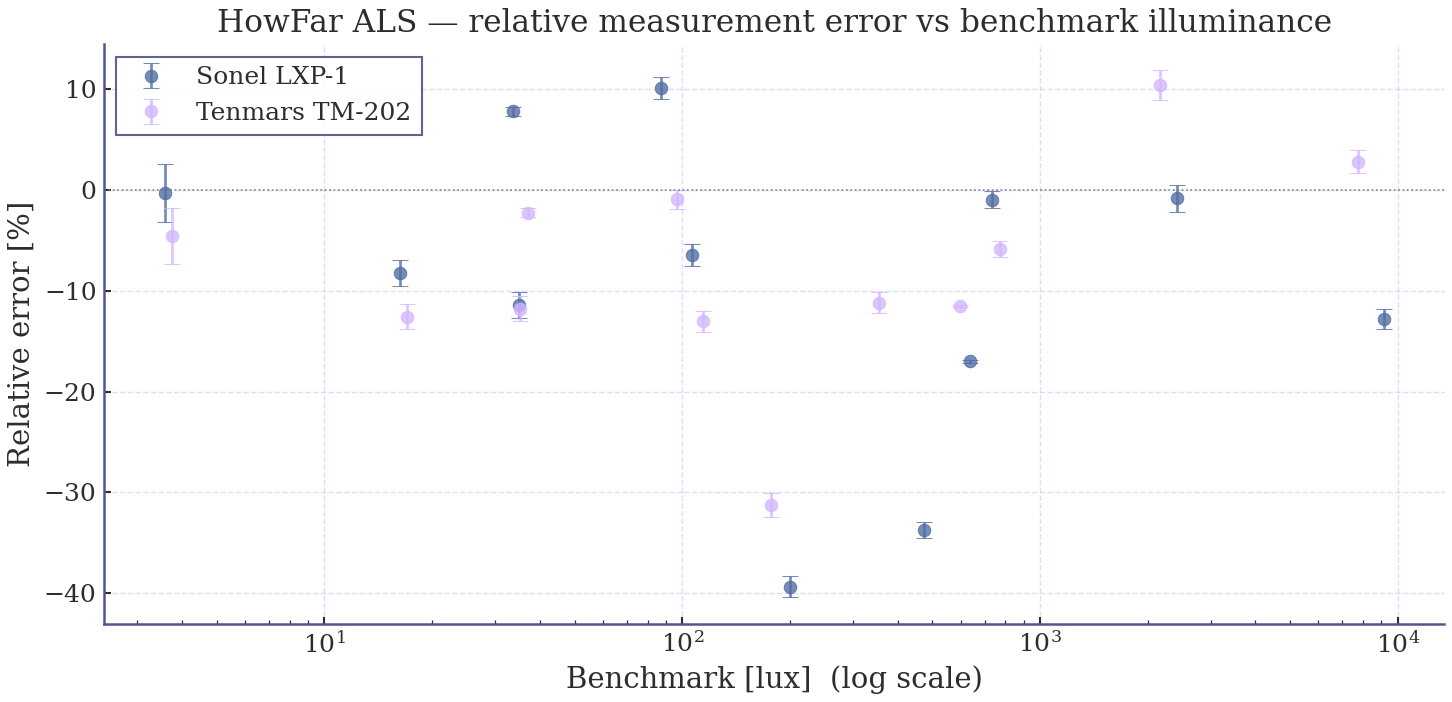

Relative error vs Sonel   — mean ± SD: -9.4 ± 14.4 %
Relative error vs Tenmars — mean ± SD: -7.7 ± 9.9 %


In [10]:
# Relative error (%): (HowFar_mean - benchmark) / benchmark * 100
# Relative SD (%):    hf_std / benchmark * 100  (error propagation for division by constant)
relerr_s   = err_sonel   / sonel_bm   * 100
relerr_t   = err_tenmars / tenmars_bm * 100
relstd_s   = hf_stds / sonel_bm   * 100
relstd_t   = hf_stds / tenmars_bm * 100

fig, ax = plt.subplots(figsize=(10, 5))

for bm, relerr, relstd, col, lbl in [
    (sonel_bm,   relerr_s, relstd_s, C_S, 'Sonel LXP-1'),
    (tenmars_bm, relerr_t, relstd_t, C_T, 'Tenmars TM-202'),
]:
    order = np.argsort(bm)
    ax.errorbar(bm[order], relerr[order], yerr=relstd[order],
                fmt='o', color=col, ecolor=col, alpha=0.8,
                capsize=4, linewidth=1.3, markersize=6, label=lbl)

ax.axhline(0, color='grey', linewidth=0.8, linestyle=':')
ax.set_xscale('log')
ax.set_xlabel('Benchmark [lux]  (log scale)')
ax.set_ylabel('Relative error [%]')
ax.set_title('HowFar ALS — relative measurement error vs benchmark illuminance')
ax.legend()
plt.tight_layout()
fig.savefig('figs/ch5/fig_5_als_relerr.pdf', bbox_inches='tight', dpi=300)
print('Saved: figs/ch5/fig_5_als_relerr.pdf')
plt.show()

print('Relative error vs Sonel   — mean ± SD: {:.1f} ± {:.1f} %'.format(relerr_s.mean(), relerr_s.std()))
print('Relative error vs Tenmars — mean ± SD: {:.1f} ± {:.1f} %'.format(relerr_t.mean(), relerr_t.std()))

## 9. Bland–Altman Agreement Plots

x-axis: mean of HowFar and benchmark; y-axis: HowFar − benchmark.  
Dashed lines: mean difference ± 1.96 SD (95 % limits of agreement).

Saved: figs/app/fig_app_als_ba_sonel.pdf
Saved: figs/app/fig_app_als_ba_tenmars.pdf


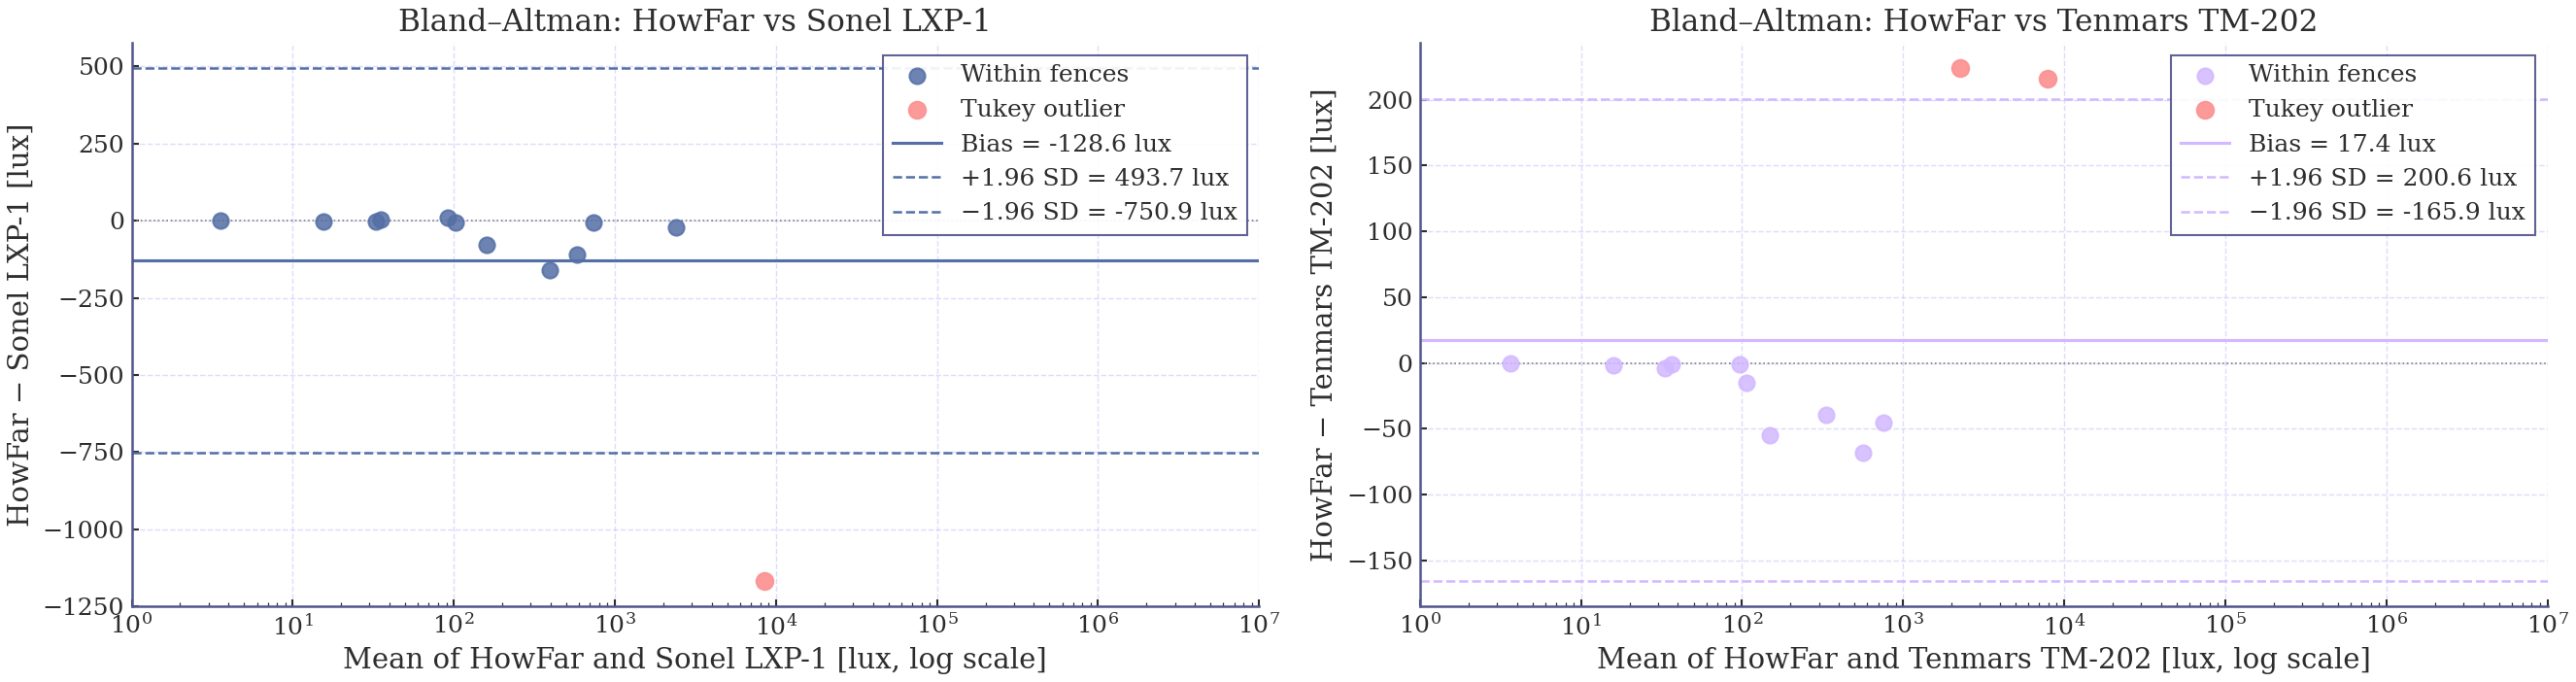

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

for ax, bm, diff, col, lbl in [
    (axes[0], sonel_bm,   err_sonel,   C_S, 'Sonel LXP-1'),
    (axes[1], tenmars_bm, err_tenmars, C_T, 'Tenmars TM-202'),
]:
    mean_val = (hf_means + bm) / 2
    bias     = diff.mean()
    loa_hi   = bias + 1.96 * diff.std()
    loa_lo   = bias - 1.96 * diff.std()

    q1, q3 = np.percentile(diff, [25, 75])
    iqr = q3 - q1
    out_mask = (diff < q1 - 1.5 * iqr) | (diff > q3 + 1.5 * iqr)
    ax.scatter(mean_val[~out_mask], diff[~out_mask], color=col,   s=60, zorder=3, alpha=0.85, label='Within fences')
    ax.scatter(mean_val[out_mask],  diff[out_mask],  color=C_OUT, s=70, zorder=4, alpha=0.95, label='Tukey outlier')

    ax.axhline(bias,   color=col,    linewidth=1.5, linestyle='-',
               label=f'Bias = {bias:.1f} lux')
    ax.axhline(loa_hi, color=col,    linewidth=1.2, linestyle='--',
               label=f'+1.96 SD = {loa_hi:.1f} lux')
    ax.axhline(loa_lo, color=col,    linewidth=1.2, linestyle='--',
               label=f'−1.96 SD = {loa_lo:.1f} lux')
    ax.axhline(0, color='grey', linewidth=0.8, linestyle=':')

    ax.set_xscale('log')
    ax.set_xlim(1, 1e7)
    ax.set_xlabel('Mean of HowFar and {} [lux, log scale]'.format(lbl))
    ax.set_ylabel('HowFar − {} [lux]'.format(lbl))
    ax.set_title('Bland–Altman: HowFar vs {}'.format(lbl))
    ax.legend(loc='upper right')
plt.tight_layout()
fig.savefig('figs/app/fig_app_als_ba_combined.pdf', bbox_inches='tight', dpi=300)

import matplotlib.pyplot as _plt2
for _fname, _bm, _diff, _col, _lbl in [
    ('figs/app/fig_app_als_ba_sonel.pdf',   sonel_bm,   err_sonel,   C_S, 'Sonel LXP-1'),
    ('figs/app/fig_app_als_ba_tenmars.pdf', tenmars_bm, err_tenmars, C_T, 'Tenmars TM-202'),
]:
    _fig, _ax = _plt2.subplots(figsize=(7, 5))
    _mean_val = (hf_means + _bm) / 2
    _bias  = _diff.mean()
    _lo_hi = _bias + 1.96 * _diff.std()
    _lo_lo = _bias - 1.96 * _diff.std()
    _q1, _q3 = np.percentile(_diff, [25, 75])
    _iqr = _q3 - _q1
    _out_mask = (_diff < _q1 - 1.5 * _iqr) | (_diff > _q3 + 1.5 * _iqr)
    _ax.scatter(_mean_val[~_out_mask], _diff[~_out_mask], color=_col,   s=60, zorder=3, alpha=0.85, label='Within fences')
    _ax.scatter(_mean_val[_out_mask],  _diff[_out_mask],  color=C_OUT,  s=70, zorder=4, alpha=0.95, label='Tukey outlier')
    _ax.axhline(_bias,  color=_col, linewidth=1.5, linestyle='-',  label=f'Bias = {_bias:.1f} lux')
    _ax.axhline(_lo_hi, color=_col, linewidth=1.2, linestyle='--', label=f'+1.96 SD = {_lo_hi:.1f} lux')
    _ax.axhline(_lo_lo, color=_col, linewidth=1.2, linestyle='--', label=f'\u22121.96 SD = {_lo_lo:.1f} lux')
    _ax.axhline(0, color='grey', linewidth=0.8, linestyle=':')
    _ax.set_xscale('log')
    _ax.set_xlim(1, 1e7)
    _ax.set_xlabel(f'Mean of HowFar and {_lbl} [lux, log scale]')
    _ax.set_ylabel(f'HowFar \u2212 {_lbl} [lux]')
    _ax.set_title(f'Bland\u2013Altman: HowFar vs {_lbl}')
    _ax.legend(loc='upper right')
    _plt2.tight_layout()
    _fig.savefig(_fname, bbox_inches='tight', dpi=300)
    _plt2.close(_fig)
    print(f'Saved: {_fname}')

plt.show()

## 10. Tukey Outlier Detection
Identifies Bland–Altman outliers using standard Tukey fences [Q1 − 1.5×IQR, Q3 + 1.5×IQR]; results are used to annotate the §5.2.2 figures in Section 11.

In [12]:
tukey_results = {}
for diff, bm, lbl in [
    (err_sonel,   sonel_bm,   'HF - Sonel'),
    (err_tenmars, tenmars_bm, 'HF - Tenmars'),
]:
    q1, q3 = np.percentile(diff, [25, 75])
    iqr    = q3 - q1
    lo     = q1 - 1.5 * iqr
    hi     = q3 + 1.5 * iqr
    flags  = np.where((diff < lo) | (diff > hi))[0]
    tukey_results[lbl] = dict(q1=q1, q3=q3, iqr=iqr, lo=lo, hi=hi, flags=flags)
    print(f'{lbl}:')
    print(f'  Q1 = {q1:.2f} lux   Q3 = {q3:.2f} lux   IQR = {iqr:.2f} lux')
    print(f'  Tukey fences: [{lo:.2f},  {hi:.2f}] lux')
    if len(flags):
        for idx in flags:
            loc_name = ref_data[idx][0]
            b_val    = bm[idx]
            d_val    = diff[idx]
            print(f'  Outlier #{idx+1}: "{loc_name}" | benchmark = {b_val:.1f} lux | diff = {d_val:.2f} lux')
    else:
        print('  No outliers detected.')
    print()

HF - Sonel:
  Q1 = -86.13 lux   Q3 = -1.01 lux   IQR = 85.12 lux
  Tukey fences: [-213.82,  126.68] lux
  Outlier #4: "Direct sunlight" | benchmark = 9126.0 lux | diff = -1167.88 lux

HF - Tenmars:
  Q1 = -41.00 lux   Q3 = -0.67 lux   IQR = 40.33 lux
  Tukey fences: [-101.49,  59.81] lux
  Outlier #2: "Natural, near window" | benchmark = 2164.0 lux | diff = 223.97 lux
  Outlier #4: "Direct sunlight" | benchmark = 7742.0 lux | diff = 216.12 lux



## 11. Bland–Altman with Tukey Annotations (main text, §5.2.2)

Outliers identified by standard Tukey fences [Q1 − 1.5×IQR, Q3 + 1.5×IQR] are highlighted in grapefruit pink. Individual panels saved to `figs/ch5/` for §5.2.2.

In [13]:
import os
os.makedirs('figs/ch5', exist_ok=True)

for _bm, _diff, _col, _lbl, _fname in [
    (sonel_bm,   err_sonel,   C_S, 'Sonel LXP-1',    'figs/ch5/fig_5_als_ba_sonel.pdf'),
    (tenmars_bm, err_tenmars, C_T, 'Tenmars TM-202', 'figs/ch5/fig_5_als_ba_tenmars.pdf'),
]:
    _key    = 'HF - Sonel' if 'Sonel' in _lbl else 'HF - Tenmars'
    _flags  = tukey_results[_key]['flags']
    _bias   = _diff.mean()
    _loa_hi = _bias + 1.96 * _diff.std()
    _loa_lo = _bias - 1.96 * _diff.std()
    _mean_v = (hf_means + _bm) / 2

    _normal = np.array([i for i in range(len(_diff)) if i not in _flags])
    _out    = _flags

    _fig, _ax = plt.subplots(figsize=(10, 5))
    if len(_normal):
        _ax.scatter(_mean_v[_normal], _diff[_normal],
                    color=_col, s=60, zorder=3, alpha=0.85, label='Within fences')
    if len(_out):
        _ax.scatter(_mean_v[_out], _diff[_out],
                    color=C_OUT, s=70, zorder=4, alpha=0.95, label='Tukey outlier')
    _ax.axhline(_bias,   color=_col, linewidth=1.5, linestyle='-',
                label=f'Bias = {_bias:.1f} lux')
    _ax.axhline(_loa_hi, color=_col, linewidth=1.2, linestyle='--',
                label=f'+1.96 SD = {_loa_hi:.1f} lux')
    _ax.axhline(_loa_lo, color=_col, linewidth=1.2, linestyle='--',
                label=f'-1.96 SD = {_loa_lo:.1f} lux')
    _ax.axhline(0, color='grey', linewidth=0.8, linestyle=':')
    _ax.set_xscale('log')
    _ax.set_xlabel(f'Mean of HowFar and {_lbl} [lux, log scale]')
    _ax.set_ylabel(f'HowFar minus {_lbl} [lux]')
    _ax.set_title(f'Bland-Altman: HowFar vs {_lbl}')
    _ax.legend(loc='upper right')
    plt.tight_layout(pad=0.4)
    _fig.savefig(_fname, bbox_inches='tight', dpi=300)
    plt.close(_fig)
    print(f'Saved: {_fname}')

Saved: figs/ch5/fig_5_als_ba_sonel.pdf
Saved: figs/ch5/fig_5_als_ba_tenmars.pdf


## 12. Log–Log Correlation Scatter

The data spans ~4 orders of magnitude; a log–log scale reveals structure at low illuminance that a linear scale would hide. Identity line (y = x) shows perfect agreement; regression line shows the actual systematic relationship.

In [14]:
plot_data = [
    (sonel_bm, C_S, 'Sonel LXP-1', 'figs/app/fig_app_als_loglog_sonel.pdf', 'figs/ch4/fig_4_calibration_regression_sonel.pdf', 'figs/ch5/fig_5_als_scatter_sonel.pdf'),
    (tenmars_bm, C_T, 'Tenmars TM-202', 'figs/app/fig_app_als_loglog_tenmars.pdf', 'figs/ch4/fig_4_calibration_regression_tenmars.pdf', 'figs/ch5/fig_5_als_scatter_tenmars.pdf'),
]

for bm, col, lbl, save_path_app, save_path_ch4, save_path_ch5 in plot_data:
    fig, ax = plt.subplots(figsize=(7, 5))

    log_bm = np.log10(bm)
    log_hf = np.log10(hf_means)
    sl, ic, r, p, _ = stats.linregress(log_bm, log_hf)

    ax.scatter(bm, hf_means, color=col, s=60, zorder=3, alpha=0.85, label='Measurements')

    x_range = np.logspace(np.log10(bm.min() * 0.8), np.log10(1e5), 300)
    ax.plot(x_range, x_range, 'k--', linewidth=1.0, label='Identity line (y\u202f=\u202fx)')
    ax.plot(x_range, 10**ic * x_range**sl, color=col, linewidth=1.5,
            label=f'Regression  R\u00b2={r**2:.3f}\ny = {10**ic:.3f}\u00b7x^{{{sl:.3f}}}')

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel(f'{lbl} [lux]')
    ax.set_ylabel('HowFar ALS mean [lux]')
    ax.set_title(f'HowFar vs {lbl}')
    ax.legend()
    ax.set_xlim(x_range.min(), x_range.max())

    plt.tight_layout()

    fig.savefig(save_path_app, bbox_inches='tight', dpi=300)
    print(f'Saved: {save_path_app}')
    fig.savefig(save_path_ch4, bbox_inches='tight', dpi=300)
    print(f'Saved: {save_path_ch4}')
    fig.savefig(save_path_ch5, bbox_inches='tight', dpi=300)
    print(f'Saved: {save_path_ch5}')

    plt.close(fig)
plt.show()

Saved: figs/app/fig_app_als_loglog_sonel.pdf
Saved: figs/ch4/fig_4_calibration_regression_sonel.pdf
Saved: figs/ch5/fig_5_als_scatter_sonel.pdf
Saved: figs/app/fig_app_als_loglog_tenmars.pdf
Saved: figs/ch4/fig_4_calibration_regression_tenmars.pdf
Saved: figs/ch5/fig_5_als_scatter_tenmars.pdf


## 13. Error Plot (Fig. 6A) — Log x-axis

Same uncalibrated error data as above, with a log x-axis to show low-light behaviour alongside high-light conditions without compression.

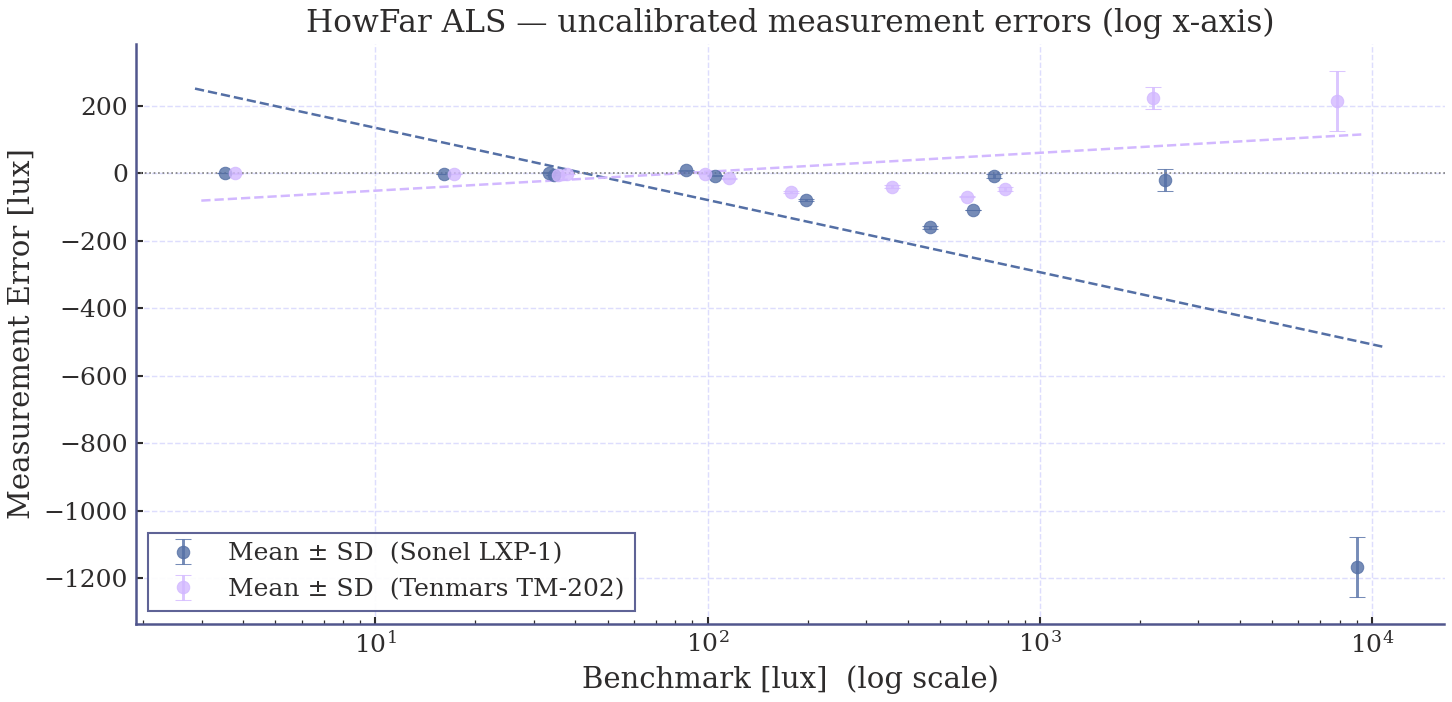

In [15]:
fig, ax = plt.subplots(figsize=(10, 5))

for bm, err, std, col, lbl in [
    (sonel_bm,   err_sonel,   hf_stds, C_S, 'Sonel LXP-1'),
    (tenmars_bm, err_tenmars, hf_stds, C_T, 'Tenmars TM-202'),
]:
    xoff = bm * (1 - OFF) if col == C_S else bm * (1 + OFF)
    ax.errorbar(xoff, err, yerr=std, fmt='o', color=col, ecolor=col, alpha=0.8,
                capsize=4, linewidth=1.4, markersize=6, label=f'Mean ± SD  ({lbl})')
    # Trend line in log-x space
    log_bm = np.log10(bm)
    sl_e, ic_e, *_ = stats.linregress(log_bm, err)
    x_tr = np.logspace(np.log10(bm.min() * 0.8), np.log10(bm.max() * 1.2), 300)
    ax.plot(x_tr, sl_e * np.log10(x_tr) + ic_e, color=col, linestyle='--', linewidth=1.2)

ax.axhline(0, color='grey', linewidth=0.8, linestyle=':')
ax.set_xscale('log')
ax.set_xlabel('Benchmark [lux]  (log scale)')
ax.set_ylabel('Measurement Error [lux]')
ax.set_title('HowFar ALS — uncalibrated measurement errors (log x-axis)')
ax.legend()
plt.tight_layout()
plt.show()